In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
dataset_path = "/content/gdrive/MyDrive/Emotion_Project/datasets/TESS/TESS Toronto emotional speech set data"

In [ ]:
paths = []
emotions = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(
        dataset_path,
        folder
    )

    if os.path.isdir(folder_path):

        for file in os.listdir(folder_path):

            if file.endswith(".wav"):

                file_path = os.path.join(
                    folder_path,
                    file
                )

                emotion = file.split("_")[-1]
                emotion = emotion.replace(".wav", "")

                paths.append(file_path)
                emotions.append(emotion)

In [ ]:
df = pd.DataFrame({
    "path": paths,
    "emotion": emotions
})

In [ ]:
print(df.head())

                                                path emotion
0  /content/gdrive/MyDrive/Emotion_Project/datase...    fear
1  /content/gdrive/MyDrive/Emotion_Project/datase...    fear
2  /content/gdrive/MyDrive/Emotion_Project/datase...    fear
3  /content/gdrive/MyDrive/Emotion_Project/datase...    fear
4  /content/gdrive/MyDrive/Emotion_Project/datase...    fear


In [ ]:
print(df['emotion'].value_counts())

emotion
fear       400
ps         400
sad        400
angry      400
disgust    400
happy      400
neutral    400
Name: count, dtype: int64


In [ ]:
os.listdir(dataset_path)

['OAF_Fear',
 'OAF_Pleasant_surprise',
 'OAF_Sad',
 'OAF_angry',
 'OAF_disgust',
 'OAF_happy',
 'OAF_neutral',
 'YAF_angry',
 'YAF_disgust',
 'YAF_fear',
 'YAF_happy',
 'YAF_neutral',
 'YAF_pleasant_surprised',
 'YAF_sad']

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['emotion']
)

In [ ]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['emotion']
)

In [ ]:
print("Train:", len(train_df))

print("Validation:", len(val_df))

print("Test:", len(test_df))

Train: 1792
Validation: 448
Test: 560


In [ ]:
def extract_mfcc(file_path):

    signal, sr = librosa.load(
        file_path,
        sr=22050
    )

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=40
    )

    mfcc = mfcc.T

    max_pad_length = 130

    if mfcc.shape[0] < max_pad_length:

        pad_width = max_pad_length - mfcc.shape[0]

        mfcc = np.pad(
            mfcc,
            pad_width=((0, pad_width), (0, 0)),
            mode='constant'
        )

    else:

        mfcc = mfcc[:max_pad_length]

    return mfcc

In [ ]:
X_train = []
y_train = []

In [ ]:
for index, row in train_df.iterrows():

    mfcc = extract_mfcc(row['path'])

    X_train.append(mfcc)

    y_train.append(row['emotion'])

In [ ]:
X_train = np.array(X_train)

y_train = np.array(y_train)

In [ ]:
print(X_train.shape)

print(y_train.shape)

(1792, 130, 40)
(1792,)


In [ ]:
X_val = []

y_val = []

In [ ]:
for index, row in val_df.iterrows():

    mfcc = extract_mfcc(row['path'])

    X_val.append(mfcc)

    y_val.append(row['emotion'])

In [ ]:
X_val = np.array(X_val)

y_val = np.array(y_val)

In [ ]:
X_test = []

y_test = []

In [ ]:
for index, row in test_df.iterrows():

    mfcc = extract_mfcc(row['path'])

    X_test.append(mfcc)

    y_test.append(row['emotion'])

In [ ]:
X_test = np.array(X_test)

y_test = np.array(y_test)

In [ ]:
print(X_train.shape)

print(X_val.shape)

print(X_test.shape)

(1792, 130, 40)
(448, 130, 40)
(560, 130, 40)


In [ ]:
label_encoder = LabelEncoder()

In [ ]:
y_train_encoded = label_encoder.fit_transform(
    y_train
)

In [ ]:
y_val_encoded = label_encoder.transform(
    y_val
)

In [ ]:
y_test_encoded = label_encoder.transform(
    y_test
)

In [ ]:
print(label_encoder.classes_)

['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']


In [ ]:
y_train_encoded = to_categorical(
    y_train_encoded
)

In [ ]:
y_val_encoded = to_categorical(
    y_val_encoded
)

In [ ]:
y_test_encoded = to_categorical(
    y_test_encoded
)

In [ ]:
print(y_train_encoded.shape)

print(y_val_encoded.shape)

print(y_test_encoded.shape)

(1792, 7)
(448, 7)
(560, 7)


In [ ]:
model = Sequential()

In [ ]:
model.add(

    Conv1D(
        64,
        kernel_size=3,
        activation='relu',
        input_shape=(130, 40)
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(
    MaxPooling1D(
        pool_size=2
    )
)

In [ ]:
model.add(
    BatchNormalization()
)

In [ ]:
model.add(

    Bidirectional(

        LSTM(
            64
        )
    )
)

In [ ]:
model.add(
    Dropout(0.3)
)

In [ ]:
model.add(
    Dense(
        64,
        activation='relu'
    )
)

In [ ]:
model.add(
    Dropout(0.3)
)

In [ ]:
model.add(
    Dense(
        7,
        activation='softmax'
    )
)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,759 (323.28 KB)

 Trainable params: 82,631 (322.78 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(

    X_train,
    y_train_encoded,

    validation_data=(
        X_val,
        y_val_encoded
    ),

    epochs=30,

    batch_size=32,

    callbacks=[early_stopping]
)

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5391 - loss: 1.3149 - val_accuracy: 0.8036 - val_loss: 0.6531
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9671 - loss: 0.1516 - val_accuracy: 0.9866 - val_loss: 0.0506
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9894 - loss: 0.0479 - val_accuracy: 0.9732 - val_loss: 0.0601
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9944 - loss: 0.0329 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9967 - loss: 0.0179 - val_accuracy: 0.9955 - val_loss: 0.0153
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9961 - loss: 0.0193 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9994 - loss: 0.0075 - val_accuracy: 1.0000 - val_loss: 6.7241e-04
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 1.000

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_encoded
)

print("Test Accuracy:", test_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9982 - loss: 0.0057
Test Accuracy: 0.9982143044471741


1. ACCURACY GRAPH

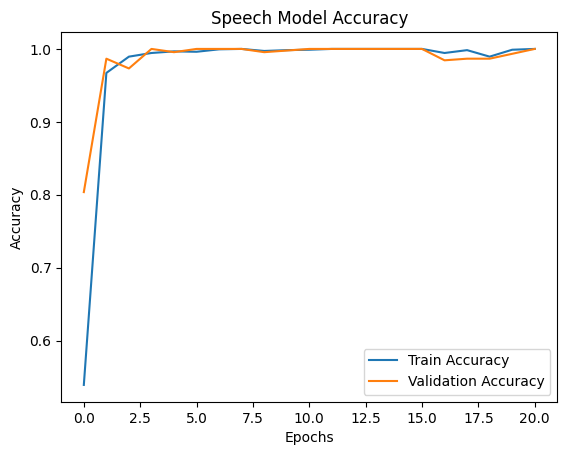

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.title('Speech Model Accuracy')

plt.legend()

plt.show()
plt.savefig(
    "/content/gdrive/MyDrive/Emotion_Project/results/speech_accuracy.png"
)

2. LOSS GRAPH

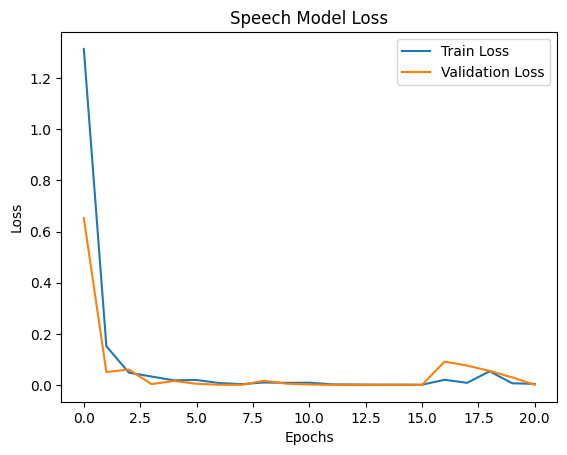

In [ ]:
plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.title('Speech Model Loss')

plt.legend()

plt.savefig(
    "/content/gdrive/MyDrive/Emotion_Project/results/speech_loss.png"
)

plt.show()

3. CONFUSION MATRIX

In [ ]:
y_pred = model.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [ ]:
y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

In [ ]:
y_true = np.argmax(
    y_test_encoded,
    axis=1
)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred_classes
)

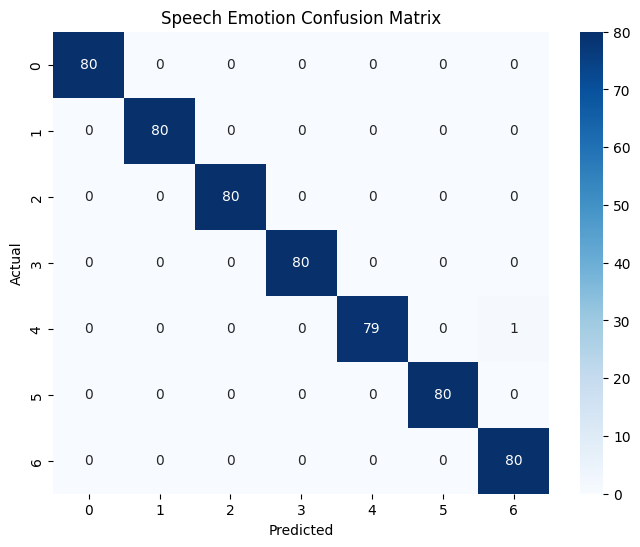

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Speech Emotion Confusion Matrix')

plt.savefig(
    "/content/gdrive/MyDrive/Emotion_Project/results/speech_confusion_matrix.png"
)

plt.show()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       1.00      1.00      1.00        80
     disgust       1.00      1.00      1.00        80
        fear       1.00      1.00      1.00        80
       happy       1.00      1.00      1.00        80
     neutral       1.00      0.99      0.99        80
          ps       1.00      1.00      1.00        80
         sad       0.99      1.00      0.99        80

    accuracy                           1.00       560
   macro avg       1.00      1.00      1.00       560
weighted avg       1.00      1.00      1.00       560



In [ ]:
model.save(
    "/content/gdrive/MyDrive/Emotion_Project/saved_models/speech_model_fixed.keras"
)